# Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install boto3
!pip install awscli

BASE = '/content/drive/MyDrive/Image-Text Retrieval'

import pandas as pd
import numpy as np
from PIL import Image

os.makedirs(f'{BASE}/listings', exist_ok=True)
os.makedirs(f'{BASE}/images_meta', exist_ok=True)
os.makedirs(f'{BASE}/small_images', exist_ok=True)

folderlist = ['00','01','02','03','04','05','06','07','08','09','0a','0b','0c','0d','0e','0f','10','11','12',
              '13','14','15','16','17','18','19','1a','1b','1c','1d','1e','1f','20','21','22','23','24','25',
              '26','27','28','29','2a','2b','2c','2d','2e','2f','30','31','32','33','34','35','36','37','38',
              '39','3a','3b','3c','3d','3e','3f','40','41','42','43','44','45','46','47','48','49','4a','4b',
              '4c','4d','4e','4f','50','51','52','53','54','55','56','57','58','59','5a','5b','5c','5d','5e',
              '5f','60','61','62','63','64','65','66','67','68','69','6a','6b','6c','6d','6e','6f','70','71',
              '72','73','74','75','76','77','78','79','7a','7b','7c','7d','7e','7f','80','81','82','83','84',
              '85','86','87','88','89','8a','8b','8c','8d','8e','8f','90','91','92','93','94','95','96','97',
              '98','99','9a','9b','9c','9d','9e','9f','a0','a1','a2','a3','a4','a5','a6','a7','a8','a9','aa',
              'ab','ac','ad','ae','af','b0','b1','b2','b3','b4','b5','b6','b7','b8','b9','ba','bb','bc','bd',
              'be','bf','c0','c1','c2','c3','c4','c5','c6','c7','c8','c9','ca','cb','cc','cd','ce','cf','d0',
              'd1','d2','d3','d4','d5','d6','d7','d8','d9','da','db','dc','dd','de','df','e0','e1','e2','e3',
              'e4','e5','e6','e7','e8','e9','ea','eb','ec','ed','ee','ef','f0','f1','f2','f3','f4','f5','f6',
              'f7','f8','f9','fa','fb','fc','fd','fe','ff']

for folder in folderlist:
  os.makedirs(f'{BASE}/small_images/{folder}', exist_ok=True)

brands_img = pd.read_csv(f"{BASE}/brands_img.csv",index_col='Unnamed: 0')
brands_img.head(1)
import os
import torch
from IPython.display import display, Image as disp_Image, HTML
import gzip
import json
from collections import Counter
import subprocess


!pip install -U torchao
!pip install peft --quiet
from peft import LoraConfig, get_peft_model

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 23.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
from transformers import AutoModel, AutoProcessor
from PIL import Image
import torch
import pandas as pd
pd.set_option('display.max_columns', None)

from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"))


model = AutoModel.from_pretrained("openai/clip-vit-base-patch32")
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(device)  # confirm it actually says "cuda", not silently falling back to cpu

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

cpu


In [6]:
brands_img.columns

Index(['brand', 'color', 'model_name', 'item_keywords', 'product_type',
       'item_id', 'country', 'marketplace', 'main_image_id', 'node',
       'combined_text', 'ct_len', 'country_rank', 'image_id', 'height',
       'width', 'path', 'path_map'],
      dtype='object')

# Data Cleaning

In [ ]:
import subprocess

def download_if_missing(s3_path, local_path):
    if os.path.exists(local_path):
        print(f"already have {local_path}, skipping")
        return
    result = subprocess.run(
        ['aws', 's3', 'cp', '--no-sign-request', s3_path, local_path],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"FAILED: {s3_path}")
        print(result.stderr)
    else:
        print(f"downloaded: {local_path}")

def listings_gz_extract(file_name):
  data = []
  with gzip.open(f'{BASE}/listings/{file_name}', 'rt', encoding='utf-8') as f:
      print(f"opening {file_name}")
      for line in f:
          data.append(json.loads(line))

  file_df = pd.DataFrame(data)
  return file_df


def get_combined_files(all_files):
  columns_dict={}
  all_file_df = pd.DataFrame()
  for file_name in all_files:
    download_if_missing(
      f's3://amazon-berkeley-objects/listings/metadata/{file_name}',
      f'{BASE}/listings/{file_name}')

    file_df = listings_gz_extract(file_name)
    columns_dict[file_name] = file_df.columns

    all_file_df = pd.concat([all_file_df, file_df],ignore_index =True)
    print(f"appended {file_name}")

  return all_file_df

def download_if_missing_image_file(s3_path, local_path):
    if os.path.exists(local_path):
        print(f"already have {local_path}, skipping")
        return
    result = subprocess.run(
        ['aws', 's3', 'cp', '--no-sign-request', s3_path, local_path],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"FAILED: {s3_path}")
        print(result.stderr)
    else:
        print(f"downloaded: {local_path}")

def images_gz_extract(file_name):
  data = []
  file_df = pd.read_csv(f'{BASE}/images_meta/{file_name}', compression='gzip')
  return file_df
# ----   To Check wether all columns are identical or not in all the files ----
# all_cols = set()
# i=0
# for columns in columns_dict.values():
#   for column in columns:
#     all_cols.add(column)

# different_cols = {}
# for file,columns in columns_dict.items():
#   print(file, len(columns))
#   for column in columns:
#     if column not in all_cols:
#       l = []
#       l.append(column)
#       different_cols[file] = l
# print(f"not matched file and columns:  {different_cols}")

In [ ]:
## Get All the Files Data with Specific Languages and Column level logics applied
# Based on previous data exploration
import gzip
import json
import pandas as pd

english_tags = {'en_IN', 'en_US', 'en_CA', 'en_GB', 'en_AU', 'en_AE', 'en_SG'}


def extract_lang_field(raw_row, key, language_codes, join_multi=False):
    key_value = raw_row.get(key)
    if not isinstance(key_value, list):
        return ''
    matches = [pair['value'] for pair in key_value if pair.get('language_tag') in language_codes]
    if not matches:
        return ''
    if join_multi:
        matches = list(dict.fromkeys(matches))  # dedupe, preserves first-seen order
    return ' | '.join(matches) if join_multi else matches[0]

def extract_value_only(raw_row, key):
    # for columns like product_type, model_number: list of {'value': ...}, no language_tag at all
    key_value = raw_row.get(key)
    if not isinstance(key_value, list) or len(key_value) == 0:
        return ''
    return key_value[0].get('value', '')

def extract_raw(raw_row, key):
    # for plain scalar columns: item_id, country, marketplace, domain_name, main_image_id
    value = raw_row.get(key)
    return value if value is not None else ''

def extract_node_field(raw_row, key='node', join_multi=False):
    key_value = raw_row.get(key)
    if not isinstance(key_value, list) or len(key_value) == 0:
        return ''
    names = [pair.get('node_name', '') for pair in key_value if pair.get('node_name')]
    if not names:
        return ''
    return ' | '.join(names) if join_multi else names[0]

language_cols = {
    'brand': False,
    'bullet_point': True,
    'color': False,
    'item_name': False,
    'model_name': False,
    'item_keywords': True,
}
value_only_cols = ['product_type']
raw_cols = ['item_id', 'country', 'marketplace', 'main_image_id']

all_listings = [
'listings_0.json.gz',
'listings_1.json.gz',
'listings_2.json.gz',
'listings_3.json.gz',
'listings_4.json.gz',
'listings_5.json.gz',
'listings_6.json.gz',
'listings_7.json.gz',
'listings_8.json.gz',
'listings_9.json.gz',
'listings_a.json.gz',
'listings_b.json.gz',
'listings_c.json.gz',
'listings_d.json.gz',
'listings_e.json.gz',
'listings_f.json.gz']

data = []
for file_name in all_listings:
  with gzip.open(f'{BASE}/listings/{file_name}', 'rt', encoding='utf-8') as f:
      for line in f:
          raw_row = json.loads(line)
          mod_row = {}

          for col, multi in language_cols.items():
              mod_row[col] = extract_lang_field(raw_row, col, english_tags, join_multi=multi)

          for col in value_only_cols:
              mod_row[col] = extract_value_only(raw_row, col)

          for col in raw_cols:
              mod_row[col] = extract_raw(raw_row, col)

          mod_row['node'] = extract_node_field(raw_row, key='node', join_multi=False)

          data.append(mod_row)

df_final = pd.DataFrame(data)



In [ ]:
brands_df = df_final.copy()
brands_df = brands_df.replace('', np.nan)

#  Removing these rows as they are not important at any stage
cols = ['brand','bullet_point','color','item_name','model_name','item_keywords']
brands_df = brands_df[~brands_df[cols].isna().all(axis=1)]

brands_df['combined_text'] = brands_df['item_name'] + " " + brands_df['bullet_point']
brands_df = brands_df[~brands_df['combined_text'].isna()]
brands_df = brands_df.drop(columns=['item_name', 'bullet_point'])
brands_df['ct_len'] = brands_df['combined_text'].apply(len)

# Priority List
country_priority = ['IN', 'US', 'CA', 'GB', 'DE', 'MX', 'ES', 'FR', 'IT', 'JP',
                     'AU', 'NL', 'SG', 'AE', 'SE', 'SA', 'TR', 'UK', 'PL', 'BR']
priority_map = {c: i for i, c in enumerate(country_priority)}
brands_df['country_rank'] = brands_df['country'].map(priority_map).fillna(len(country_priority))


def dedup_by_group(df, group_col):
    dup_mask = df.groupby(group_col)[group_col].transform('count') > 1
    dup_subset = df[dup_mask].sort_values(
        by=[group_col, 'ct_len', 'country_rank'],
        ascending=[True, False, True]
    )
    winners = dup_subset.drop_duplicates(subset=group_col, keep='first')
    losing_indices = dup_subset.index.difference(winners.index)
    return df.drop(index=losing_indices), len(losing_indices)


brands_df, n_dropped_item = dedup_by_group(brands_df, 'item_id')
print(f"dropped {n_dropped_item} losing rows from item_id duplicates")
assert brands_df['item_id'].duplicated().sum() == 0



brands_df, n_dropped_image = dedup_by_group(brands_df, 'main_image_id')
print(f"dropped {n_dropped_image} losing rows from main_image_id duplicates")

before = len(brands_df)
brands_df = brands_df[~brands_df['main_image_id'].isna()]
print(f"dropped {before - len(brands_df)} rows with no main_image_id")

assert brands_df['main_image_id'].duplicated().sum() == 0

product_df = brands_df['product_type'].value_counts().reset_index()
new_product_df = product_df.loc[(product_df['count']>300) & (product_df['product_type']!='CELLULAR_PHONE_CASE'),'product_type']

brands_df = brands_df[brands_df['product_type'].isin(new_product_df)] # 25479 rows


Based on what we are seeing with the keywords values we need to first identify if the item keywords column offers anything extra than item_name + bullet_point.

for each listing, take the set of unique words in item_keywords and the set of unique words in your combined_text (item_name + bullet_point), and compute what fraction of item_keywords' unique vocabulary is already covered by combined_text.


# Embeddings

In [4]:

def _load_checkpoint(checkpoint_path):
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path)
        print(f"resuming from row {ckpt['next_row']} ({len(ckpt['item_ids'])} items already embedded)")
        return ckpt['embeddings'], ckpt['item_ids'], ckpt['next_row']
    return None, [], 0

def _save_checkpoint(checkpoint_path, prev_embeddings, new_embeddings_list, prev_item_ids, new_ids, next_row):
    # combine only what's new with whatever was already saved — avoids re-processing the whole history in memory
    new_tensor = torch.cat(new_embeddings_list, dim=0)
    if prev_embeddings is not None:
        combined_embeddings = torch.cat([prev_embeddings, new_tensor], dim=0)
    else:
        combined_embeddings = new_tensor
    combined_ids = prev_item_ids + new_ids

    torch.save({
        'embeddings': combined_embeddings,
        'item_ids': combined_ids,
        'next_row': next_row
    }, checkpoint_path)

    return combined_embeddings, combined_ids


def get_image_embeddings(batch_size, df, checkpoint_every=1,
                          checkpoint_path=f'{BASE}/embeddings/img_checkpoint.pt'):
    saved_embeddings, saved_item_ids, start_batch = _load_checkpoint(checkpoint_path)

    pending_embeddings = []   # only holds batches since the last checkpoint write
    pending_ids = []

    for i in range(start_batch, df.shape[0], batch_size):
        ubound = min(i + batch_size, df.shape[0])
        data = df[i:ubound]

        valid_images, valid_ids = [], []
        for p, item_id in zip(data['path_map'], data['item_id']):
            try:
                img = Image.open(p).convert('RGB')
            except Exception as e:
                print(f"skipping {p}: {e}")
                continue
            valid_images.append(img)
            valid_ids.append(item_id)

        if not valid_images:
            continue

        model_inputs = processor(images=valid_images, return_tensors="pt")
        model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

        with torch.inference_mode():
            batch_output = model.get_image_features(**model_inputs)
        batch_embeddings = batch_output.pooler_output if hasattr(batch_output, 'pooler_output') else batch_output

        pending_embeddings.append(batch_embeddings.cpu())
        pending_ids.extend(valid_ids)

        print(f"processed {ubound}/{df.shape[0]}")

        if (i // batch_size) % checkpoint_every == 0:
            saved_embeddings, saved_item_ids = _save_checkpoint(
                checkpoint_path, saved_embeddings, pending_embeddings,
                saved_item_ids, pending_ids, next_row=ubound
            )
            pending_embeddings, pending_ids = [], []  # cleared — already folded into saved_embeddings
            print(f"checkpoint saved at row {ubound}, total so far: {len(saved_item_ids)}")

    # final flush for any leftover batches since the last checkpoint
    if pending_embeddings:
        saved_embeddings, saved_item_ids = _save_checkpoint(
            checkpoint_path, saved_embeddings, pending_embeddings,
            saved_item_ids, pending_ids, next_row=df.shape[0]
        )

    return saved_embeddings, saved_item_ids


def get_text_embeddings(batch_size, df, checkpoint_every=1,
                         checkpoint_path=f'{BASE}/embeddings/text_checkpoint.pt'):
    saved_embeddings, saved_item_ids, start_batch = _load_checkpoint(checkpoint_path)

    pending_embeddings = []
    pending_ids = []

    for i in range(start_batch, df.shape[0], batch_size):
        ubound = min(i + batch_size, df.shape[0])
        data = df[i:ubound]

        valid_text, valid_ids = [], []
        for text_val, item_id in zip(data['combined_text'], data['item_id']):
            if not isinstance(text_val, str) or text_val.strip() == '':
                print(f"skipping empty text for item_id {item_id}")
                continue
            valid_text.append(text_val)
            valid_ids.append(item_id)

        if not valid_text:
            continue

        model_inputs = processor(text=valid_text, return_tensors="pt",
                                  truncation=True, max_length=77, padding=True)
        model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

        with torch.inference_mode():
            batch_output = model.get_text_features(**model_inputs)
        batch_embeddings = batch_output.pooler_output if hasattr(batch_output, 'pooler_output') else batch_output

        pending_embeddings.append(batch_embeddings.cpu())
        pending_ids.extend(valid_ids)

        print(f"processed {ubound}/{df.shape[0]}")

        if (i // batch_size) % checkpoint_every == 0:
            saved_embeddings, saved_item_ids = _save_checkpoint(
                checkpoint_path, saved_embeddings, pending_embeddings,
                saved_item_ids, pending_ids, next_row=ubound
            )
            pending_embeddings, pending_ids = [], []
            print(f"checkpoint saved at row {ubound}, total so far: {len(saved_item_ids)}")

    if pending_embeddings:
        saved_embeddings, saved_item_ids = _save_checkpoint(
            checkpoint_path, saved_embeddings, pending_embeddings,
            saved_item_ids, pending_ids, next_row=df.shape[0]
        )

    return saved_embeddings, saved_item_ids

In [ ]:
image_embeds, image_item_ids = get_image_embeddings(512, brands_img)
text_embeds, text_item_ids = get_text_embeddings(512, brands_img)

image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

np.save(f'{BASE}/embeddings/catalog_image_embeds.npy', image_embeds.cpu().numpy())
np.save(f'{BASE}/embeddings/catalog_text_embeds.npy', text_embeds.cpu().numpy())
pd.DataFrame({'item_id': image_item_ids}).to_csv(f'{BASE}/embeddings/catalog_item_ids.csv', index=False)

In [30]:
import torch
import numpy as np

def verify_embeddings(checkpoint_path, expected_df, label=""):
    print(f"--- Verifying {label} ---")

    if not os.path.exists(checkpoint_path):
        print("FAILED: checkpoint file does not exist at all")
        return None, None

    ckpt = torch.load(checkpoint_path)
    embeddings = ckpt['embeddings']
    item_ids = ckpt['item_ids']

    # 1. Basic shape sanity
    print(f"embeddings shape: {embeddings.shape}")
    print(f"item_ids length: {len(item_ids)}")

    # 2. Do embeddings and item_ids actually match in count?
    if embeddings.shape[0] != len(item_ids):
        print(f"FAILED: mismatch — {embeddings.shape[0]} embeddings vs {len(item_ids)} item_ids")
    else:
        print("OK: embeddings and item_ids counts match")

    # 3. Coverage — how much of the original dataframe actually got embedded?
    expected_ids = set(expected_df['item_id'])
    got_ids = set(item_ids)
    missing = expected_ids - got_ids
    extra = got_ids - expected_ids

    print(f"expected: {len(expected_ids)}, got: {len(got_ids)}")
    print(f"missing (in df but not embedded): {len(missing)}")
    print(f"extra (embedded but not in df — shouldn't happen): {len(extra)}")

    # 4. Duplicate check — should never have the same item_id embedded twice
    dupes = len(item_ids) - len(set(item_ids))
    print(f"duplicate item_ids in embedding list: {dupes}")

    # 5. Sanity on the actual values — catch all-zero or NaN embeddings (a sign something silently broke)
    nan_count = torch.isnan(embeddings).any(dim=1).sum().item()
    zero_count = (embeddings.abs().sum(dim=1) == 0).sum().item()
    print(f"rows with NaN values: {nan_count}")
    print(f"rows that are all-zero: {zero_count}")

    # 6. Norm check — post-normalization, every row's L2 norm should be ~1.0
    norms = embeddings.norm(dim=1)
    print(f"embedding norms — min: {norms.min():.4f}, max: {norms.max():.4f}, mean: {norms.mean():.4f}")
    print("(if you haven't normalized yet, these won't be ~1.0 — that's expected until you do)")

    return embeddings, item_ids


img_embeds, img_ids = verify_embeddings(f'{BASE}/embeddings/img_checkpoint.pt', brands_img, label="images")
text_embeds, text_ids = verify_embeddings(f'{BASE}/embeddings/text_checkpoint.pt', brands_img, label="text")

# 7. Cross-check: do image and text embeddings cover the exact same set of item_ids?
if img_ids is not None and text_ids is not None:
    common = set(img_ids) & set(text_ids)
    only_img = set(img_ids) - set(text_ids)
    only_text = set(text_ids) - set(img_ids)
    print(f"\ncommon to both: {len(common)}")
    print(f"only in images: {len(only_img)}")
    print(f"only in text: {len(only_text)}")

--- Verifying images ---
embeddings shape: torch.Size([25479, 512])
item_ids length: 25479
OK: embeddings and item_ids counts match
expected: 25479, got: 25479
missing (in df but not embedded): 0
extra (embedded but not in df — shouldn't happen): 0
duplicate item_ids in embedding list: 0
rows with NaN values: 0
rows that are all-zero: 0
embedding norms — min: 7.8919, max: 12.6960, mean: 10.4368
(if you haven't normalized yet, these won't be ~1.0 — that's expected until you do)
--- Verifying text ---
embeddings shape: torch.Size([25479, 512])
item_ids length: 25479
OK: embeddings and item_ids counts match
expected: 25479, got: 25479
missing (in df but not embedded): 0
extra (embedded but not in df — shouldn't happen): 0
duplicate item_ids in embedding list: 0
rows with NaN values: 0
rows that are all-zero: 0
embedding norms — min: 5.9141, max: 12.0403, mean: 6.7318
(if you haven't normalized yet, these won't be ~1.0 — that's expected until you do)

common to both: 25479
only in images: 

# Query Ranking

In [ ]:
img_npy = np.load(f'{BASE}/embeddings/catalog_image_embeds.npy')
img_tensor = torch.from_numpy(img_npy)
text_npy = np.load(f'{BASE}/embeddings/catalog_text_embeds.npy')
text_tensor = torch.from_numpy(text_npy)
item_ids = pd.read_csv(f'{BASE}/embeddings/catalog_item_ids.csv')

# pd.DataFrame({'item_id': image_item_ids}).to_csv(f'{BASE}/embeddings/catalog_item_ids.csv', index=False)
# print("image norms:", np.linalg.norm(img_npy, axis=1).min(), np.linalg.norm(img_npy, axis=1).max())
# print("text norms:", np.linalg.norm(text_npy, axis=1).min(), np.linalg.norm(text_npy, axis=1).max())

In [26]:

def retrieve_top_k(query,catalog_embed,item_ids,catalog_df,top=10,is_image_to_text = False):

  if is_image_to_text:
    print("4_11")
    valid_images = []
    for p in query:
        print(f"opening: {p}")
        try:
            img = Image.open(p).convert('RGB')
        except Exception as e:
            print(f"skipping {p}: {e}")
            continue
        valid_images.append(img)

        if not valid_images:
          print("no valid images in query — returning empty result")
          return pd.DataFrame()
    print("4_12")
    model_inputs = processor(images=valid_images, return_tensors="pt")
    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

    with torch.inference_mode():
      output_embeddings = model.get_image_features(**model_inputs)

  else:
    print("4_13")
    if not query:
        print("no valid text in query — returning empty result")
        return pd.DataFrame()

    model_inputs = processor(text = query,return_tensors="pt",truncation=True, max_length=77, padding=True)
    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

    print("4_14")
    with torch.inference_mode():
      output_embeddings = model.get_text_features(**model_inputs)
  print("4_15")
  output_embeddings = output_embeddings.pooler_output if hasattr(output_embeddings, 'pooler_output') else output_embeddings
  output_embeddings = output_embeddings.cpu()

  output_embeddings = output_embeddings / output_embeddings.norm(dim=-1, keepdim=True)
  similarity_mat = torch.matmul(catalog_embed,output_embeddings.T)
  top_candidates_idx = torch.topk(similarity_mat, top,dim=0,largest=True, sorted=True).indices
  print("4_16")
  top_candidates_idx = pd.DataFrame(top_candidates_idx)

  top_item_ids = pd.DataFrame()
  for column in top_candidates_idx.columns:
    query_item_ids = item_ids.iloc[top_candidates_idx[column]].reset_index().drop(columns='index').rename(columns={'item_id': f'query_{column}'})
    top_item_ids = pd.concat([top_item_ids,query_item_ids],axis=1)
  print("4_17")
  return top_item_ids


def show_images_from_item_ids(catalog_df,item_ids):

  image_paths = catalog_df.loc[catalog_df['item_id'].isin(item_ids),'path_map']
  # Sequential display
  for path in image_paths:
      display(disp_Image(filename=path))

def show_text_from_item_ids(catalog_df,item_ids):

  retrieved_text = catalog_df.loc[catalog_df['item_id'].isin(item_ids),['model_name','item_keywords','combined_text']]

  return retrieved_text


In [ ]:
query = ['A photo of Shoes','a photo of laptop']
top_items = retrieve_top_k(query,img_tensor,item_ids,brands_img,10,is_image_to_text=False)

show_images_from_item_ids(brands_img,top_items['query_0'].tolist())

In [ ]:
brands_img['path_map'].sample(2).tolist()

In [ ]:
# query = brands_img['path_map'].sample(2).tolist()
query = ['/content/drive/MyDrive/Image-Text Retrieval/small_images/7f/76e72f10.jpg']
valid_images = []
for p in query:
    try:
         img = Image.open(p).convert('RGB')
    except Exception as e:
        print(f"skipping {p}: {e}")
        continue
    valid_images.append(img)

    if not valid_images:
      print("no valid images in query — returning empty result")


# model_inputs = processor(images=valid_images, return_tensors="pt")
# model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

# with torch.inference_mode():
#   output_embeddings = model.get_image_features(**model_inputs)

In [ ]:
query = []
if not query:
  print("hello there")

In [ ]:
query = ['A photo of Shoes','A Photo of laptop']
processed_text = processor(text = query,return_tensors="pt",truncation=True, max_length=77, padding=True)
processed_text = {k: v.to(device) for k, v in processed_text.items()}
with torch.inference_mode():
    text_embeddings = model.get_text_features(**processed_text)

text_embeddings = text_embeddings.pooler_output if hasattr(text_embeddings, 'pooler_output') else text_embeddings

text_embeddings = text_embeddings.cpu()



In [ ]:
text_embeddings.T.shape

In [ ]:
img_tensor.shape


In [ ]:
top_item_ids = pd.DataFrame()
similarity_mat = torch.matmul(img_tensor,text_embeddings.T)

top_candidates_idx = torch.topk(similarity_mat, 10,dim=0,largest=True, sorted=True).indices

top_candidates_idx = pd.DataFrame(top_candidates_idx)
top_candidates_idx

for column in top_candidates_idx.columns:

  query_item_ids = item_ids.iloc[top_candidates_idx[column]].reset_index().drop(columns='index').rename(columns={'item_id': f'query_{column}'})
  top_item_ids = pd.concat([top_item_ids,query_item_ids],axis=1)
# top_items = pd.merge(brands_img,top_item_ids,how = 'inner', left_on = 'item_id',right_on='item_id')
# top_items
top_item_ids



# Modeling 1

In [31]:
from sklearn.model_selection import train_test_split


train_df, test_df = train_test_split(
    brands_img,
    test_size=0.20,
    stratify=brands_img['product_type'],
    random_state=42)

print(f"train_pool: {len(train_df)} rows")
print(f"test: {len(test_df)} rows")


print("\ncategory share, full catalog vs test set:")
full_dist = brands_img['product_type'].value_counts(normalize=True)
test_dist = test_df['product_type'].value_counts(normalize=True)
comparison = pd.DataFrame({'full': full_dist, 'test': test_dist})
print(comparison)

# save just the item_ids — this file is the permanent, reusable reference for every future model
test_df[['item_id']].to_csv(f'{BASE}/embeddings/test_query_ids.csv', index=False)
train_df[['item_id']].to_csv(f'{BASE}/embeddings/train_pool_ids.csv', index=False)

print(f"\nsaved test set ({len(test_df)} items) and train ({len(train_df)} items) to Drive")

train_pool: 20383 rows
test: 5096 rows

category share, full catalog vs test set:
                                full      test
product_type                                  
ACCESSORY                   0.013148  0.013148
BEAUTY                      0.012638  0.012559
BOOT                        0.013933  0.013932
CHAIR                       0.054398  0.054356
FINEEARRING                 0.024609  0.024725
FINENECKLACEBRACELETANKLET  0.032026  0.031986
FINERING                    0.019232  0.019231
GROCERY                     0.181012  0.181122
HANDBAG                     0.026178  0.026295
HARDWARE_HANDLE             0.014208  0.014129
HEALTH_PERSONAL_CARE        0.036344  0.036303
HOME                        0.060049  0.060047
HOME_BED_AND_BATH           0.026924  0.026884
HOME_FURNITURE_AND_DECOR    0.038816  0.038854
KITCHEN                     0.016563  0.016484
LAMP                        0.017151  0.017072
LIGHT_BULB                  0.012520  0.012559
LIGHT_FIXTURE            

In [5]:
test_query_ids = pd.read_csv(f'{BASE}/embeddings/test_query_ids.csv')

In [2]:
def evaluate_text_to_image_recall(test_df, catalog_embed, catalog_item_ids, k_values=[1, 5, 10], batch_size=32):
    results = {k: {'hits': 0, 'evaluated': 0} for k in k_values}
    per_category_results = {}

    max_k = max(k_values)
    test_df = test_df.reset_index(drop=True)

    for start in range(0, len(test_df), batch_size):
        end = min(start + batch_size, len(test_df))
        batch = test_df.iloc[start:end]

        print("3_1")

        queries = batch['combined_text'].tolist()
        top_items = retrieve_top_k(
            query=queries,
            catalog_embed=catalog_embed,
            item_ids=catalog_item_ids,
            catalog_df=None,
            top=max_k,
            is_image_to_text=False
        )
        print("3_2")
        if top_items.empty:
            continue

        for position, (_, row) in enumerate(batch.iterrows()):
            col_name = f'query_{position}'
            if col_name not in top_items.columns:
                continue

            true_item_id = row['item_id']
            category = row['product_type']
            retrieved_ids = top_items[col_name].tolist()

            if category not in per_category_results:
                per_category_results[category] = {k: {'hits': 0, 'evaluated': 0} for k in k_values}
            print("3_3")
            for k in k_values:
                results[k]['evaluated'] += 1
                per_category_results[category][k]['evaluated'] += 1
                if true_item_id in retrieved_ids[:k]:
                    results[k]['hits'] += 1
                    per_category_results[category][k]['hits'] += 1

    return results, per_category_results


def evaluate_image_to_text_recall(test_df, catalog_embed, catalog_item_ids, k_values=[1, 5, 10], batch_size=32):
    results = {k: {'hits': 0, 'evaluated': 0} for k in k_values}
    per_category_results = {}

    max_k = max(k_values)
    test_df = test_df.reset_index(drop=True)

    for start in range(0, len(test_df), batch_size):
        end = min(start + batch_size, len(test_df))
        batch = test_df.iloc[start:end]
        print("4_1")
        queries = batch['path_map'].tolist()   # images as query input now
        top_items = retrieve_top_k(
            query=queries,
            catalog_embed=catalog_embed,        # searching TEXT catalog now
            item_ids=catalog_item_ids,
            catalog_df=None,
            top=max_k,
            is_image_to_text=True
        )

        if top_items.empty:
            continue
        print("4_2")
        for position, (_, row) in enumerate(batch.iterrows()):
            col_name = f'query_{position}'
            if col_name not in top_items.columns:
                continue

            true_item_id = row['item_id']
            category = row['product_type']
            retrieved_ids = top_items[col_name].tolist()

            if category not in per_category_results:
                per_category_results[category] = {k: {'hits': 0, 'evaluated': 0} for k in k_values}
            print("4_3")
            for k in k_values:
                results[k]['evaluated'] += 1
                per_category_results[category][k]['evaluated'] += 1
                if true_item_id in retrieved_ids[:k]:
                    results[k]['hits'] += 1
                    per_category_results[category][k]['hits'] += 1

    return results, per_category_results

In [7]:

test_ids_df = pd.read_csv(f'{BASE}/embeddings/test_query_ids.csv')
test_df = brands_img[brands_img['item_id'].isin(test_ids_df['item_id'])].reset_index(drop=True)

print(f"test set size: {len(test_df)}")

item_ids_df = pd.read_csv(f'{BASE}/embeddings/catalog_item_ids.csv')
catalog_item_ids = item_ids_df['item_id']

image_embeds_tensor = torch.tensor(np.load(f'{BASE}/embeddings/catalog_image_embeds.npy'))
text_embeds_tensor = torch.tensor(np.load(f'{BASE}/embeddings/catalog_text_embeds.npy'))



test set size: 5096


In [8]:
t2i_results, t2i_per_category = evaluate_text_to_image_recall(
    test_df, image_embeds_tensor, catalog_item_ids, k_values=[1, 5, 10]
)

print("\n--- Text to Image ---")
for k, r in t2i_results.items():
    print(f"Recall@{k}: {r['hits']}/{r['evaluated']} = {r['hits']/r['evaluated']:.4f}")

for category, cat_results in i2t_per_category.items():
    row = f"{category}: "
    for k in [1, 5, 10]:
        r = cat_results[k]
        rate = r['hits']/r['evaluated'] if r['evaluated'] > 0 else float('nan')
        row += f"R@{k}={rate:.3f} (n={r['evaluated']})  "
    print(row)

Streaming output truncated to the last 5000 lines.
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_

In [10]:

i2t_results, i2t_per_category = evaluate_image_to_text_recall(
    test_df, text_embeds_tensor, catalog_item_ids, k_values=[1, 5, 10]
)

# Print overall numbers for both directions


print("\n--- Image to Text ---")
for k, r in i2t_results.items():
    print(f"Recall@{k}: {r['hits']}/{r['evaluated']} = {r['hits']/r['evaluated']:.4f}")

# Per-category breakdown, one direction shown as example
print("\n--- Per-category (Text to Image) ---")
for category, cat_results in t2i_per_category.items():
    row = f"{category}: "
    for k in [1, 5, 10]:
        r = cat_results[k]
        rate = r['hits']/r['evaluated'] if r['evaluated'] > 0 else float('nan')
        row += f"R@{k}={rate:.3f} (n={r['evaluated']})  "
    print(row)

Streaming output truncated to the last 5000 lines.
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_1
4_11
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/43/431de557.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/54/54cdd028.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/68/68a90dc1.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/34/34b8b74f.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/26/26759e74.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/41/41387e63.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/23/23b19da7.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/de/de51c6d4.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/93/932bf1f8.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/2f/2fdd0ca3.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/16/16caae56.jpg
opening: /


--- Image to Text ---
Recall@1: 621/5096 = 0.1219
Recall@5: 1494/5096 = 0.2932
Recall@10: 1942/5096 = 0.3811

--- Per-category (Text to Image) ---
BEAUTY: R@1=0.141 (n=64)  R@5=0.250 (n=64)  R@10=0.359 (n=64)  
OFFICE_PRODUCTS: R@1=0.129 (n=85)  R@5=0.259 (n=85)  R@10=0.376 (n=85)  
BOOT: R@1=0.099 (n=71)  R@5=0.225 (n=71)  R@10=0.268 (n=71)  
SHOES: R@1=0.040 (n=963)  R@5=0.129 (n=963)  R@10=0.177 (n=963)  
GROCERY: R@1=0.308 (n=923)  R@5=0.644 (n=923)  R@10=0.758 (n=923)  
ACCESSORY: R@1=0.209 (n=67)  R@5=0.567 (n=67)  R@10=0.746 (n=67)  
RUG: R@1=0.026 (n=152)  R@5=0.079 (n=152)  R@10=0.151 (n=152)  
HOME: R@1=0.127 (n=306)  R@5=0.304 (n=306)  R@10=0.392 (n=306)  
SPORTING_GOODS: R@1=0.158 (n=76)  R@5=0.382 (n=76)  R@10=0.526 (n=76)  
KITCHEN: R@1=0.095 (n=84)  R@5=0.452 (n=84)  R@10=0.607 (n=84)  
HOME_FURNITURE_AND_DECOR: R@1=0.091 (n=198)  R@5=0.177 (n=198)  R@10=0.253 (n=198)  
FINENECKLACEBRACELETANKLET: R@1=0.196 (n=163)  R@5=0.368 (n=163)  R@10=0.491 (n=163)  
CHAIR: R@1=0.0

BEAUTY: R@1=0.234 (n=64)  R@5=0.375 (n=64)  R@10=0.469 (n=64)  
OFFICE_PRODUCTS: R@1=0.129 (n=85)  R@5=0.400 (n=85)  R@10=0.518 (n=85)  
BOOT: R@1=0.070 (n=71)  R@5=0.254 (n=71)  R@10=0.338 (n=71)  
SHOES: R@1=0.049 (n=963)  R@5=0.128 (n=963)  R@10=0.188 (n=963)  
GROCERY: R@1=0.213 (n=923)  R@5=0.457 (n=923)  R@10=0.563 (n=923)  
ACCESSORY: R@1=0.224 (n=67)  R@5=0.582 (n=67)  R@10=0.731 (n=67)  
RUG: R@1=0.026 (n=152)  R@5=0.072 (n=152)  R@10=0.079 (n=152)  
HOME: R@1=0.111 (n=306)  R@5=0.268 (n=306)  R@10=0.373 (n=306)  
SPORTING_GOODS: R@1=0.250 (n=76)  R@5=0.474 (n=76)  R@10=0.566 (n=76)  
KITCHEN: R@1=0.155 (n=84)  R@5=0.488 (n=84)  R@10=0.619 (n=84)  
HOME_FURNITURE_AND_DECOR: R@1=0.111 (n=198)  R@5=0.187 (n=198)  R@10=0.263 (n=198)  
FINENECKLACEBRACELETANKLET: R@1=0.178 (n=163)  R@5=0.368 (n=163)  R@10=0.485 (n=163)  
CHAIR: R@1=0.058 (n=277)  R@5=0.184 (n=277)  R@10=0.260 (n=277)  
WALL_ART: R@1=0.293 (n=92)  R@5=0.870 (n=92)  R@10=0.902 (n=92)  
LIGHT_BULB: R@1=0.047 (n=64)  

## Results
--- Text to Image ---
Recall@1: 666/5096 = 0.1307
Recall@5: 1586/5096 = 0.3112
Recall@10: 2044/5096 = 0.4011

BEAUTY: R@1=0.234 (n=64)  R@5=0.375 (n=64)  R@10=0.469 (n=64)  
OFFICE_PRODUCTS: R@1=0.129 (n=85)  R@5=0.400 (n=85)  R@10=0.518 (n=85)  
BOOT: R@1=0.070 (n=71)  R@5=0.254 (n=71)  R@10=0.338 (n=71)  
SHOES: R@1=0.049 (n=963)  R@5=0.128 (n=963)  R@10=0.188 (n=963)  
GROCERY: R@1=0.213 (n=923)  R@5=0.457 (n=923)  R@10=0.563 (n=923)  
ACCESSORY: R@1=0.224 (n=67)  R@5=0.582 (n=67)  R@10=0.731 (n=67)  
RUG: R@1=0.026 (n=152)  R@5=0.072 (n=152)  R@10=0.079 (n=152)  
HOME: R@1=0.111 (n=306)  R@5=0.268 (n=306)  R@10=0.373 (n=306)  
SPORTING_GOODS: R@1=0.250 (n=76)  R@5=0.474 (n=76)  R@10=0.566 (n=76)  
KITCHEN: R@1=0.155 (n=84)  R@5=0.488 (n=84)  R@10=0.619 (n=84)  
HOME_FURNITURE_AND_DECOR: R@1=0.111 (n=198)  R@5=0.187 (n=198)  R@10=0.263 (n=198)  
FINENECKLACEBRACELETANKLET: R@1=0.178 (n=163)  R@5=0.368 (n=163)  R@10=0.485 (n=163)  
CHAIR: R@1=0.058 (n=277)  R@5=0.184 (n=277)  R@10=0.260 (n=277)  
WALL_ART: R@1=0.293 (n=92)  R@5=0.870 (n=92)  R@10=0.902 (n=92)  
LIGHT_BULB: R@1=0.047 (n=64)  R@5=0.172 (n=64)  R@10=0.281 (n=64)  
STOOL_SEATING: R@1=0.090 (n=67)  R@5=0.179 (n=67)  R@10=0.239 (n=67)  
SOFA: R@1=0.018 (n=165)  R@5=0.097 (n=165)  R@10=0.133 (n=165)  
HEALTH_PERSONAL_CARE: R@1=0.265 (n=185)  R@5=0.535 (n=185)  R@10=0.638 (n=185)  
TABLE: R@1=0.081 (n=136)  R@5=0.272 (n=136)  R@10=0.368 (n=136)  
HOME_BED_AND_BATH: R@1=0.102 (n=137)  R@5=0.263 (n=137)  R@10=0.372 (n=137)  
LAMP: R@1=0.115 (n=87)  R@5=0.287 (n=87)  R@10=0.483 (n=87)  
LIGHT_FIXTURE: R@1=0.101 (n=89)  R@5=0.258 (n=89)  R@10=0.348 (n=89)  
PET_SUPPLIES: R@1=0.075 (n=80)  R@5=0.275 (n=80)  R@10=0.425 (n=80)  
HANDBAG: R@1=0.075 (n=134)  R@5=0.246 (n=134)  R@10=0.373 (n=134)  
FINERING: R@1=0.071 (n=98)  R@5=0.276 (n=98)  R@10=0.306 (n=98)  
FINEEARRING: R@1=0.111 (n=126)  R@5=0.317 (n=126)  R@10=0.421 (n=126)  
OUTDOOR_LIVING: R@1=0.225 (n=71)  R@5=0.465 (n=71)  R@10=0.577 (n=71)  
OTTOMAN: R@1=0.078 (n=64)  R@5=0.172 (n=64)  R@10=0.219 (n=64)  
HARDWARE_HANDLE: R@1=0.056 (n=72)  R@5=0.153 (n=72)  R@10=0.236 (n=72)  


--- Image to Text ---
Recall@1: 621/5096 = 0.1219
Recall@5: 1494/5096 = 0.2932
Recall@10: 1942/5096 = 0.3811

--- Per-category (Text to Image) ---
BEAUTY: R@1=0.141 (n=64)  R@5=0.250 (n=64)  R@10=0.359 (n=64)  
OFFICE_PRODUCTS: R@1=0.129 (n=85)  R@5=0.259 (n=85)  R@10=0.376 (n=85)  
BOOT: R@1=0.099 (n=71)  R@5=0.225 (n=71)  R@10=0.268 (n=71)  
SHOES: R@1=0.040 (n=963)  R@5=0.129 (n=963)  R@10=0.177 (n=963)  
GROCERY: R@1=0.308 (n=923)  R@5=0.644 (n=923)  R@10=0.758 (n=923)  
ACCESSORY: R@1=0.209 (n=67)  R@5=0.567 (n=67)  R@10=0.746 (n=67)  
RUG: R@1=0.026 (n=152)  R@5=0.079 (n=152)  R@10=0.151 (n=152)  
HOME: R@1=0.127 (n=306)  R@5=0.304 (n=306)  R@10=0.392 (n=306)  
SPORTING_GOODS: R@1=0.158 (n=76)  R@5=0.382 (n=76)  R@10=0.526 (n=76)  
KITCHEN: R@1=0.095 (n=84)  R@5=0.452 (n=84)  R@10=0.607 (n=84)  
HOME_FURNITURE_AND_DECOR: R@1=0.091 (n=198)  R@5=0.177 (n=198)  R@10=0.253 (n=198)  
FINENECKLACEBRACELETANKLET: R@1=0.196 (n=163)  R@5=0.368 (n=163)  R@10=0.491 (n=163)  
CHAIR: R@1=0.061 (n=277)  R@5=0.166 (n=277)  R@10=0.238 (n=277)  
WALL_ART: R@1=0.337 (n=92)  R@5=0.728 (n=92)  R@10=0.837 (n=92)  
LIGHT_BULB: R@1=0.031 (n=64)  R@5=0.062 (n=64)  R@10=0.109 (n=64)  
STOOL_SEATING: R@1=0.045 (n=67)  R@5=0.134 (n=67)  R@10=0.299 (n=67)  
SOFA: R@1=0.036 (n=165)  R@5=0.109 (n=165)  R@10=0.170 (n=165)  
HEALTH_PERSONAL_CARE: R@1=0.205 (n=185)  R@5=0.514 (n=185)  R@10=0.649 (n=185)  
TABLE: R@1=0.088 (n=136)  R@5=0.221 (n=136)  R@10=0.331 (n=136)  
HOME_BED_AND_BATH: R@1=0.080 (n=137)  R@5=0.204 (n=137)  R@10=0.321 (n=137)  
LAMP: R@1=0.092 (n=87)  R@5=0.299 (n=87)  R@10=0.402 (n=87)  
LIGHT_FIXTURE: R@1=0.079 (n=89)  R@5=0.191 (n=89)  R@10=0.258 (n=89)  
PET_SUPPLIES: R@1=0.075 (n=80)  R@5=0.263 (n=80)  R@10=0.338 (n=80)  
HANDBAG: R@1=0.097 (n=134)  R@5=0.254 (n=134)  R@10=0.343 (n=134)  
FINERING: R@1=0.082 (n=98)  R@5=0.245 (n=98)  R@10=0.367 (n=98)  
FINEEARRING: R@1=0.103 (n=126)  R@5=0.397 (n=126)  R@10=0.492 (n=126)  
OUTDOOR_LIVING: R@1=0.127 (n=71)  R@5=0.394 (n=71)  R@10=0.465 (n=71)  
OTTOMAN: R@1=0.047 (n=64)  R@5=0.125 (n=64)  R@10=0.172 (n=64)  
HARDWARE_HANDLE: R@1=0.028 (n=72)  R@5=0.056 (n=72)  R@10=0.083 (n=72)  

Correlation between text-to-image and image-to-text Recall@10, across all 29 categories: Pearson r = 0.916, Spearman ρ = 0.925 (p < 0.001). That's a very strong, statistically robust relationship

# Modeling 2

In [10]:
for name, module in model.named_modules():
    print(name)


text_model
text_model.embeddings
text_model.embeddings.token_embedding
text_model.embeddings.position_embedding
text_model.encoder
text_model.encoder.layers
text_model.encoder.layers.0
text_model.encoder.layers.0.self_attn
text_model.encoder.layers.0.self_attn.k_proj
text_model.encoder.layers.0.self_attn.v_proj
text_model.encoder.layers.0.self_attn.q_proj
text_model.encoder.layers.0.self_attn.out_proj
text_model.encoder.layers.0.layer_norm1
text_model.encoder.layers.0.mlp
text_model.encoder.layers.0.mlp.activation_fn
text_model.encoder.layers.0.mlp.fc1
text_model.encoder.layers.0.mlp.fc2
text_model.encoder.layers.0.layer_norm2
text_model.encoder.layers.1
text_model.encoder.layers.1.self_attn
text_model.encoder.layers.1.self_attn.k_proj
text_model.encoder.layers.1.self_attn.v_proj
text_model.encoder.layers.1.self_attn.q_proj
text_model.encoder.layers.1.self_attn.out_proj
text_model.encoder.layers.1.layer_norm1
text_model.encoder.layers.1.mlp
text_model.encoder.layers.1.mlp.activation_f

In [7]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total parameters: {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")
print(f"trainable %: {100 * trainable_params / total_params:.2f}%")

total parameters: 151,277,313
trainable parameters: 151,277,313
trainable %: 100.00%


In [22]:
target_modules = ["q_proj", "k_proj", "v_proj", "out_proj"]
modules_to_save=["visual_projection", "text_projection"]

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
    modules_to_save=["visual_projection", "text_projection"],
    lora_dropout=0.1,
    bias="none",
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters() # confirm the parameter reduction is real

trainable params: 1,638,400 || all params: 152,915,713 || trainable%: 1.0714


In [9]:
from sklearn.model_selection import train_test_split

train_pool_ids_df = pd.read_csv(f'{BASE}/embeddings/train_pool_ids.csv')
train_pool_df = brands_img[brands_img['item_id'].isin(train_pool_ids_df['item_id'])]

train_df, val_df = train_test_split(
    train_pool_df,
    test_size=0.15,
    stratify=train_pool_df['product_type'],
    random_state=42
)

print(f"train: {len(train_df)}, val: {len(val_df)}")

train_df[['item_id']].to_csv(f'{BASE}/embeddings/train_ids.csv', index=False)
val_df[['item_id']].to_csv(f'{BASE}/embeddings/val_ids.csv', index=False)

train: 17325, val: 3058


In [10]:
test_ids = set(pd.read_csv(f'{BASE}/embeddings/test_query_ids.csv')['item_id'])
train_ids = set(train_df['item_id'])
val_ids = set(val_df['item_id'])

print("train ∩ val:", len(train_ids & val_ids))
print("train ∩ test:", len(train_ids & test_ids))
print("val ∩ test:", len(val_ids & test_ids))
print("total covered:", len(train_ids | val_ids | test_ids), "vs", len(brands_img))

train ∩ val: 0
train ∩ test: 0
val ∩ test: 0
total covered: 25479 vs 25479


In [11]:
from torch.optim import AdamW

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],  #  the ~1.6M LoRA + projection params
    lr=5e-5
)

In [12]:
import time
import torch.nn.functional as F

image_cache = {}

from concurrent.futures import ThreadPoolExecutor, as_completed

def load_one(p):
    try:
        return p, Image.open(p).convert('RGB')
    except Exception:
        return p, None
def preload_images_parallel(df, max_workers=16, print_every=500):
    paths = [p for p in df['path_map'] if p not in image_cache]
    failed = 0
    completed = 0
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(load_one, p) for p in paths]
        for future in as_completed(futures):
            p, img = future.result()
            if img is None:
                failed += 1
            else:
                image_cache[p] = img
            completed += 1

            if completed % print_every == 0:
                print(f"processed {completed}/{len(paths)} ({failed} failed so far)")

    print(f"done — cached {len(image_cache)} images, {failed} failed")


def train_one_epoch(model, train_df, optimizer, batch_size=32, device=device, print_every=20):
    model.train()
    train_df = train_df.sample(frac=1).reset_index(drop=True)
    total_loss = 0
    n_batches = 0
    epoch_start = time.time()

    for start in range(0, len(train_df), batch_size):
        batch_start = time.time()
        end = min(start + batch_size, len(train_df))
        batch = train_df.iloc[start:end]

        valid_images, valid_texts = [], []
        for p, text in zip(batch['path_map'], batch['combined_text']):
            img = image_cache.get(p)
            if img is None:
                continue
            valid_images.append(img)
            valid_texts.append(text)

        if len(valid_images) < 2:
            continue

        inputs = processor(images=valid_images, text=valid_texts,
                            return_tensors="pt", truncation=True, max_length=77, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        labels = torch.arange(outputs.logits_per_image.shape[0], device=device)
        loss = (F.cross_entropy(outputs.logits_per_image, labels) +
                F.cross_entropy(outputs.logits_per_text, labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1
        batch_time = time.time() - batch_start

        if n_batches % print_every == 0:
            print(f"  batch {n_batches}/{len(train_df)//batch_size + 1} | loss: {loss.item():.4f} | {batch_time:.2f}s/batch")

    epoch_time = time.time() - epoch_start
    print(f"epoch complete: avg_loss={total_loss/n_batches:.4f}, time={epoch_time:.1f}s")
    return total_loss / n_batches


def evaluate_loss(model, val_df, batch_size=32, device=device):
    model.eval()
    total_loss = 0
    n_batches = 0
    with torch.no_grad():
        for start in range(0, len(val_df), batch_size):
            end = min(start + batch_size, len(val_df))
            batch = val_df.iloc[start:end]

            valid_images, valid_texts = [], []
            for p, text in zip(batch['path_map'], batch['combined_text']):
                img = image_cache.get(p)
                if img is None:
                    continue
                valid_images.append(img)
                valid_texts.append(text)

            if len(valid_images) < 2:
                continue

            inputs = processor(images=valid_images, text=valid_texts,
                                return_tensors="pt", truncation=True, max_length=77, padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)
            labels = torch.arange(outputs.logits_per_image.shape[0], device=device)
            loss = (F.cross_entropy(outputs.logits_per_image, labels) +
                    F.cross_entropy(outputs.logits_per_text, labels)) / 2

            total_loss += loss.item()
            n_batches += 1

    return total_loss / n_batches

In [13]:
print(f"preload started")
start = time.time()
preload_images_parallel(train_df)
preload_images_parallel(val_df)

print(f"preload finished in:{time.time()-start}")

preload started
processed 500/17325 (0 failed so far)
processed 1000/17325 (0 failed so far)
processed 1500/17325 (0 failed so far)
processed 2000/17325 (0 failed so far)
processed 2500/17325 (0 failed so far)
processed 3000/17325 (0 failed so far)
processed 3500/17325 (0 failed so far)
processed 4000/17325 (0 failed so far)
processed 4500/17325 (0 failed so far)
processed 5000/17325 (0 failed so far)
processed 5500/17325 (0 failed so far)
processed 6000/17325 (0 failed so far)
processed 6500/17325 (0 failed so far)
processed 7000/17325 (0 failed so far)
processed 7500/17325 (0 failed so far)
processed 8000/17325 (0 failed so far)
processed 8500/17325 (0 failed so far)
processed 9000/17325 (0 failed so far)
processed 9500/17325 (0 failed so far)
processed 10000/17325 (0 failed so far)
processed 10500/17325 (0 failed so far)
processed 11000/17325 (0 failed so far)
processed 11500/17325 (0 failed so far)
processed 12000/17325 (0 failed so far)
processed 12500/17325 (0 failed so far)
proc

In [20]:
len(image_cache.keys())

9312

In [14]:
model = model.to(device)
optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=5e-5)

n_epochs = 15
for epoch in range(n_epochs):
    train_loss = train_one_epoch(model, train_df, optimizer,print_every=64)
    val_loss = evaluate_loss(model, val_df)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    torch.save(model.state_dict(), f'{BASE}/embeddings/lora_checkpoint_epoch{epoch}.pt')

  batch 64/542 | loss: 0.0604 | 0.42s/batch
  batch 128/542 | loss: 0.4041 | 0.44s/batch
  batch 192/542 | loss: 0.1618 | 0.46s/batch
  batch 256/542 | loss: 0.0934 | 0.47s/batch
  batch 320/542 | loss: 0.0283 | 0.49s/batch
  batch 384/542 | loss: 0.1741 | 0.53s/batch
  batch 448/542 | loss: 0.2742 | 0.48s/batch
  batch 512/542 | loss: 0.1053 | 0.47s/batch
epoch complete: avg_loss=0.1816, time=254.7s
Epoch 0: train_loss=0.1816, val_loss=0.1629
  batch 64/542 | loss: 0.0867 | 0.47s/batch
  batch 128/542 | loss: 0.2682 | 0.46s/batch
  batch 192/542 | loss: 0.0747 | 0.50s/batch
  batch 256/542 | loss: 0.1331 | 0.47s/batch
  batch 320/542 | loss: 0.0346 | 0.46s/batch
  batch 384/542 | loss: 0.0938 | 0.46s/batch
  batch 448/542 | loss: 0.0261 | 0.46s/batch
  batch 512/542 | loss: 0.0818 | 0.50s/batch
epoch complete: avg_loss=0.0985, time=256.4s
Epoch 1: train_loss=0.0985, val_loss=0.1376
  batch 64/542 | loss: 0.1022 | 0.53s/batch
  batch 128/542 | loss: 0.0106 | 0.45s/batch
  batch 192/542

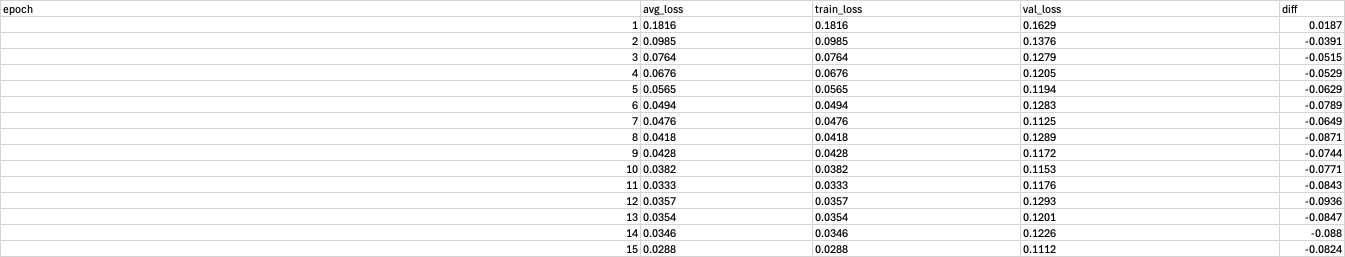


from the data we could easily say that the 15th epoch is the best one we got so far.


In [24]:
checkpoint = torch.load(f'{BASE}/embeddings/lora_checkpoint_epoch14.pt',map_location="cpu")
model.load_state_dict(checkpoint)
for k,v in checkpoint.items():
  print(k)

base_model.model.logit_scale
base_model.model.text_model.embeddings.token_embedding.weight
base_model.model.text_model.embeddings.position_embedding.weight
base_model.model.text_model.encoder.layers.0.self_attn.k_proj.base_layer.weight
base_model.model.text_model.encoder.layers.0.self_attn.k_proj.base_layer.bias
base_model.model.text_model.encoder.layers.0.self_attn.k_proj.lora_A.default.weight
base_model.model.text_model.encoder.layers.0.self_attn.k_proj.lora_B.default.weight
base_model.model.text_model.encoder.layers.0.self_attn.v_proj.base_layer.weight
base_model.model.text_model.encoder.layers.0.self_attn.v_proj.base_layer.bias
base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_A.default.weight
base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_B.default.weight
base_model.model.text_model.encoder.layers.0.self_attn.q_proj.base_layer.weight
base_model.model.text_model.encoder.layers.0.self_attn.q_proj.base_layer.bias
base_model.model.text_model.encode

In [25]:

test_ids_df = pd.read_csv(f'{BASE}/embeddings/test_query_ids.csv')
test_df = brands_img[brands_img['item_id'].isin(test_ids_df['item_id'])].reset_index(drop=True)

print(f"test set size: {len(test_df)}")

item_ids_df = pd.read_csv(f'{BASE}/embeddings/catalog_item_ids.csv')
catalog_item_ids = item_ids_df['item_id']

image_embeds_tensor = torch.tensor(np.load(f'{BASE}/embeddings/catalog_image_embeds.npy'))
text_embeds_tensor = torch.tensor(np.load(f'{BASE}/embeddings/catalog_text_embeds.npy'))



test set size: 5096


In [27]:
t2i_results, t2i_per_category = evaluate_text_to_image_recall(
    test_df, image_embeds_tensor, catalog_item_ids, k_values=[1, 5, 10]
)

print("\n--- Text to Image ---")
for k, r in t2i_results.items():
    print(f"Recall@{k}: {r['hits']}/{r['evaluated']} = {r['hits']/r['evaluated']:.4f}")

for category, cat_results in t2it_per_category.items():
    row = f"{category}: "
    for k in [1, 5, 10]:
        r = cat_results[k]
        rate = r['hits']/r['evaluated'] if r['evaluated'] > 0 else float('nan')
        row += f"R@{k}={rate:.3f} (n={r['evaluated']})  "
    print(row)

Streaming output truncated to the last 5000 lines.
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_3
3_1
4_13
4_14
4_15
4_16
4_17
3_2
3_3

NameError: name 'i2t_per_category' is not defined

In [29]:
print("\n--- Text to Image ---")
for k, r in t2i_results.items():
    print(f"Recall@{k}: {r['hits']}/{r['evaluated']} = {r['hits']/r['evaluated']:.4f}")

for category, cat_results in t2i_per_category.items():
    row = f"{category}: "
    for k in [1, 5, 10]:
        r = cat_results[k]
        rate = r['hits']/r['evaluated'] if r['evaluated'] > 0 else float('nan')
        row += f"R@{k}={rate:.3f} (n={r['evaluated']})  "
    print(row)


--- Text to Image ---
Recall@1: 965/5096 = 0.1894
Recall@5: 2171/5096 = 0.4260
Recall@10: 2763/5096 = 0.5422
BEAUTY: R@1=0.266 (n=64)  R@5=0.469 (n=64)  R@10=0.609 (n=64)  
OFFICE_PRODUCTS: R@1=0.141 (n=85)  R@5=0.400 (n=85)  R@10=0.506 (n=85)  
BOOT: R@1=0.099 (n=71)  R@5=0.296 (n=71)  R@10=0.423 (n=71)  
SHOES: R@1=0.069 (n=963)  R@5=0.227 (n=963)  R@10=0.325 (n=963)  
GROCERY: R@1=0.444 (n=923)  R@5=0.781 (n=923)  R@10=0.863 (n=923)  
ACCESSORY: R@1=0.164 (n=67)  R@5=0.537 (n=67)  R@10=0.716 (n=67)  
RUG: R@1=0.053 (n=152)  R@5=0.171 (n=152)  R@10=0.230 (n=152)  
HOME: R@1=0.150 (n=306)  R@5=0.402 (n=306)  R@10=0.510 (n=306)  
SPORTING_GOODS: R@1=0.171 (n=76)  R@5=0.487 (n=76)  R@10=0.658 (n=76)  
KITCHEN: R@1=0.155 (n=84)  R@5=0.512 (n=84)  R@10=0.679 (n=84)  
HOME_FURNITURE_AND_DECOR: R@1=0.116 (n=198)  R@5=0.298 (n=198)  R@10=0.424 (n=198)  
FINENECKLACEBRACELETANKLET: R@1=0.252 (n=163)  R@5=0.448 (n=163)  R@10=0.564 (n=163)  
CHAIR: R@1=0.105 (n=277)  R@5=0.296 (n=277)  R@10=0.

In [30]:

i2t_results, i2t_per_category = evaluate_image_to_text_recall(
    test_df, text_embeds_tensor, catalog_item_ids, k_values=[1, 5, 10]
)

# Print overall numbers for both directions


Streaming output truncated to the last 5000 lines.
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/b1/b1e7f276.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/45/45970228.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/af/af171f71.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/16/16fa3eff.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/18/1867e773.jpg
4_12
4_15
4_16
4_17
4_2
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_3
4_1
4_11
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/c8/c820ee4e.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/a8/a8e9704d.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/c7/c77cc835.jpg
opening: /content/drive/MyDrive/Image-Text Retrieval/small_images/35/35e7e8be.jpg
opening: /content/drive/MyDrive/Image-Text Retriev

In [32]:

print("\n--- Image to Text ---")
for k, r in i2t_results.items():
    print(f"Recall@{k}: {r['hits']}/{r['evaluated']} = {r['hits']/r['evaluated']:.4f}")

# Per-category breakdown, one direction shown as example
print("\n--- Per-category (Text to Image) ---")
for category, cat_results in i2t_per_category.items():
    row = f"{category}: "
    for k in [1, 5, 10]:
        r = cat_results[k]
        rate = r['hits']/r['evaluated'] if r['evaluated'] > 0 else float('nan')
        row += f"R@{k}={rate:.3f} (n={r['evaluated']})  "
    print(row)




--- Image to Text ---
Recall@1: 874/5096 = 0.1715
Recall@5: 2105/5096 = 0.4131
Recall@10: 2668/5096 = 0.5235

--- Per-category (Text to Image) ---
BEAUTY: R@1=0.219 (n=64)  R@5=0.438 (n=64)  R@10=0.609 (n=64)  
OFFICE_PRODUCTS: R@1=0.165 (n=85)  R@5=0.412 (n=85)  R@10=0.553 (n=85)  
BOOT: R@1=0.099 (n=71)  R@5=0.282 (n=71)  R@10=0.366 (n=71)  
SHOES: R@1=0.073 (n=963)  R@5=0.242 (n=963)  R@10=0.349 (n=963)  
GROCERY: R@1=0.377 (n=923)  R@5=0.735 (n=923)  R@10=0.844 (n=923)  
ACCESSORY: R@1=0.239 (n=67)  R@5=0.612 (n=67)  R@10=0.791 (n=67)  
RUG: R@1=0.072 (n=152)  R@5=0.197 (n=152)  R@10=0.263 (n=152)  
HOME: R@1=0.121 (n=306)  R@5=0.363 (n=306)  R@10=0.474 (n=306)  
SPORTING_GOODS: R@1=0.303 (n=76)  R@5=0.566 (n=76)  R@10=0.711 (n=76)  
KITCHEN: R@1=0.202 (n=84)  R@5=0.512 (n=84)  R@10=0.679 (n=84)  
HOME_FURNITURE_AND_DECOR: R@1=0.121 (n=198)  R@5=0.258 (n=198)  R@10=0.348 (n=198)  
FINENECKLACEBRACELETANKLET: R@1=0.184 (n=163)  R@5=0.393 (n=163)  R@10=0.528 (n=163)  
CHAIR: R@1=0.0